In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import label
import matplotlib.pyplot as plt

Synthetic data generation

In [10]:
def generate_synthetic_data(n_steps=15000, anomaly_prob=0.003, seed=42):
    np.random.seed(seed)
    time = np.arange(n_steps)

    # Base signal with daily seasonality and noise
    base_signal = np.sin(time * (2 * np.pi / 1440))
    noise = np.random.normal(0, 0.2, size=n_steps)
    metric = 5 + base_signal + noise
    is_incident = np.zeros(n_steps, dtype=int)

    start_points = np.where(np.random.random(n_steps) < anomaly_prob)[0]

    for start in start_points:
        if start < 100: continue

        # Precursor: gradual metric increase before the actual failure
        pre_len = 25
        metric[start-pre_len:start] += np.linspace(0, 2.0, pre_len)

        # Incident: sharp spike
        duration = np.random.randint(15, 40)
        end = min(start + duration, n_steps)
        metric[start:end] += np.random.uniform(3.5, 5.5)
        is_incident[start:end] = 1

    return pd.DataFrame({'metric': metric, 'is_incident': is_incident})

Feature engineering

In [11]:
def extract_smart_features(df, W=60):
    vals = df['metric'].values
    features = []

    for t in range(W, len(vals)):
        win = vals[t-W:t]
        short_win = vals[t-10:t] # Last 10 minutes

        f_max, f_mean, f_std = np.max(win), np.mean(win), np.std(win)

        # Dynamic features (Z-score and relative change to catch context)
        f_rel_change = np.mean(short_win) / (f_mean + 1e-6)
        f_z_score = (vals[t-1] - f_mean) / (f_std + 1e-6)

        features.append([f_max, f_mean, f_std, f_rel_change, f_z_score])

    return np.array(features), df['is_incident'].values[W:]

# Data preparation
df = generate_synthetic_data()
X_feats, y_raw = extract_smart_features(df)
H = 15 # Prediction horizon

# Target: "Will there be an incident in the next H minutes?"
y = np.array([1 if np.any(y_raw[t:t+H]) else 0 for t in range(len(y_raw)-H)])
X = X_feats[:len(y)]

# Train/Test Split (Chronological)
split = int(len(X) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Predictor model

In [12]:
# Random Forest with class balancing to penalize missed incidents
rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight={0: 1, 1: 10}, random_state=42)
rf.fit(X_train_s, y_train)
y_probs = rf.predict_proba(X_test_s)[:, 1]

Alerting algorithms

In [13]:
# Method 1: Baseline (Static Threshold + Cooldown)
def get_baseline_alerts(probs, threshold=0.3, cooldown=45):
    alerts = np.zeros(len(probs))
    cd = 0
    for i, p in enumerate(probs):
        if cd > 0:
            cd -= 1
        elif p >= threshold:
            alerts[i] = 1
            cd = cooldown
    return alerts

# Method 2: Smart LAA (Risk Accumulation + Cooldown)
class SmartAlerter:
    def __init__(self, risk_limit=3.5, start_prob=0.5, cooldown=45):
        self.risk_limit = risk_limit
        self.start_prob = start_prob
        self.cooldown = cooldown
        self.acc_risk = 0.0
        self.cd_timer = 0

    def check(self, prob):
        # Silence period after raising an alert
        if self.cd_timer > 0:
            self.cd_timer -= 1
            return 0

        if prob >= self.start_prob:
            self.acc_risk += prob
            if self.acc_risk >= self.risk_limit:
                self.acc_risk = 0.0
                self.cd_timer = self.cooldown
                return 1
        else:
            # Cool down risk if probability drops
            self.acc_risk = max(0.0, self.acc_risk - 0.5)
        return 0

y_pred_baseline = get_baseline_alerts(y_probs)
alerter = SmartAlerter()
y_pred_smart = np.array([alerter.check(p) for p in y_probs])

Event-based business evaluation and Visualization



--- BASELINE (Static 0.3 + CD) ---
Total Incidents: 9 | Caught: 9 | Missed: 0
FALSE ALERTS (SPAM): 7
Recall: 100.0% | Precision: 56.2%

--- SMART LAA (Risk Accumulation + CD) ---
Total Incidents: 9 | Caught: 9 | Missed: 0
FALSE ALERTS (SPAM): 2
Recall: 100.0% | Precision: 81.8%


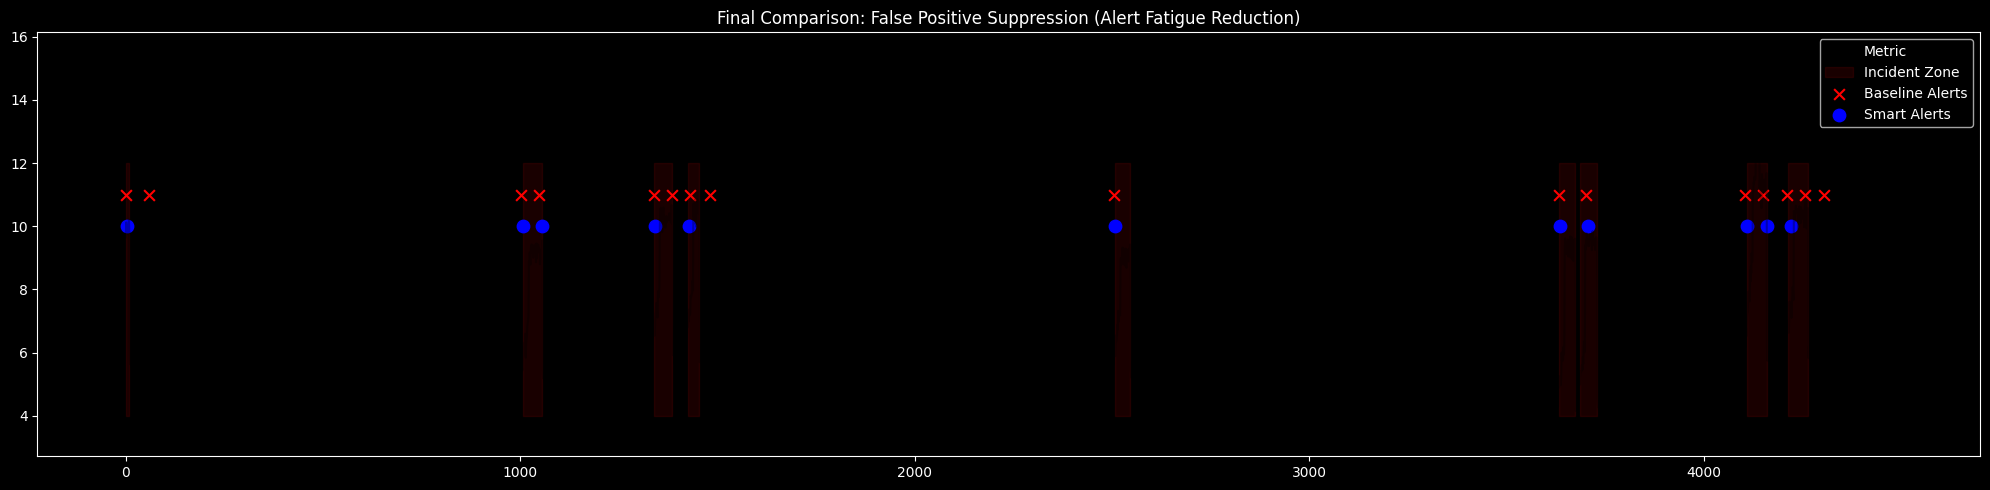

In [15]:
def business_eval(y_true, y_pred, name):
    labeled, num = label(y_true)
    caught = 0

    for i in range(1, num + 1):
        idx = np.where(labeled == i)[0]
        # Check if an alert was raised during or H minutes before the incident
        if np.any(y_pred[max(0, idx[0]-H) : idx[-1]]):
            caught += 1

    total_alerts = np.sum(y_pred)
    fp = max(0, total_alerts - caught)

    print(f"\n--- {name} ---")
    print(f"Total Incidents: {num} | Caught: {caught} | Missed: {num-caught}")
    print(f"FALSE ALERTS (SPAM): {int(fp)}")
    print(f"Recall: {caught/num:.1%} | Precision: {caught/total_alerts if total_alerts>0 else 0:.1%}")

print("\n" + "="*50)
business_eval(y_test, y_pred_baseline, "BASELINE (Static 0.3 + CD)")
business_eval(y_test, y_pred_smart, "SMART LAA (Risk Accumulation + CD)")
print("="*50)


# Visualization

plt.figure(figsize=(20, 5))
W=60

# Plot raw metric
m_plot = df['metric'].values[W+split:W+split+len(y_test)]
plt.plot(m_plot, color='black', alpha=0.3, label='Metric')

# Highlight incident zones
plt.fill_between(range(len(y_test)), 4, 12, where=(y_test==1), color='red', alpha=0.1, label='Incident Zone')

# Plot Baseline Alerts
bl_idx = np.where(y_pred_baseline == 1)[0]
plt.scatter(bl_idx, [11]*len(bl_idx), color='red', marker='x', s=60, label='Baseline Alerts')

# Plot Smart Alerts
sm_idx = np.where(y_pred_smart == 1)[0]
plt.scatter(sm_idx, [10]*len(sm_idx), color='blue', s=80, label='Smart Alerts')

plt.title("Final Comparison: False Positive Suppression (Alert Fatigue Reduction)")
plt.legend()
plt.tight_layout()
plt.show()